In [ ]:
import os
import json
import random
import datetime
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Path to your zip file inside Google Drive
zip_path = "/content/drive/MyDrive/archive.zip"

# Extract into data/ folder in Colab
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

print("Done unzipping")

Done unzipping


# Data Cleaning and EDA part

In [ ]:
print(os.getcwd())        # where Python currently "is"
print(os.path.abspath("data"))   # what "data" actually resolves to

/content
/content/data


In [ ]:
for root, dirs, files in os.walk("data"):
    print("ROOT:", root, "| files:", len(files))

ROOT: data | files: 0
ROOT: data/Testing | files: 0
ROOT: data/Testing/glioma | files: 400
ROOT: data/Testing/notumor | files: 400
ROOT: data/Testing/pituitary | files: 400
ROOT: data/Testing/meningioma | files: 400
ROOT: data/Training | files: 0
ROOT: data/Training/glioma | files: 1400
ROOT: data/Training/notumor | files: 1400
ROOT: data/Training/pituitary | files: 1400
ROOT: data/Training/meningioma | files: 1400


Block 1 (Finding and removing corrupt images)

In [ ]:
from PIL import Image
import os

bad = []

# Walk through every folder and file inside data/
for root, _, files in os.walk("data"):
    for f in files:
        full_path = os.path.join(root, f)
        try:
            Image.open(full_path).verify()
        except Exception:
            bad.append(full_path)

print(f"Corrupt images found: {len(bad)}")

# Remove them so the dataset is genuinely clean
for p in bad:
    os.remove(p)

if len(bad) > 0:
    print(f"Deleted {len(bad)} corrupt files")
else:
    print("No corrupt files - dataset is clean")

Corrupt images found: 0
No corrupt files - dataset is clean


Block 2 — Profile image sizes and colour modes

In [ ]:
from collections import Counter

sizes = Counter()
modes = Counter()

# Only Training - preprocessing decisions must come from training data only
for root, _, files in os.walk("data/Training"):
    for f in files:
        im = Image.open(os.path.join(root, f))
        sizes[im.size] += 1
        modes[im.mode] += 1

print("Total images profiled:", sum(sizes.values()))
print("\nTop 5 image sizes:")
for size, count in sizes.most_common(5):
    print(f"  {size}: {count} images")

print("\nColour modes:")
for mode, count in modes.items():
    print(f"  {mode}: {count} images")

print(f"\nNumber of distinct sizes: {len(sizes)}")

Total images profiled: 5600

Top 5 image sizes:
  (512, 512): 4012 images
  (225, 225): 253 images
  (630, 630): 69 images
  (201, 251): 40 images
  (236, 236): 39 images

Colour modes:
  L: 2358 images
  RGB: 3238 images
  RGBA: 3 images
  P: 1 images

Number of distinct sizes: 381


Block 3 - EDA part

Training set:
  glioma        : 1400
  meningioma    : 1400
  notumor       : 1400
  pituitary     : 1400
  TOTAL         : 5600

Testing set:
  glioma        : 400
  meningioma    : 400
  notumor       : 400
  pituitary     : 400
  TOTAL         : 1600

Imbalance ratio (largest/smallest): 1.00x


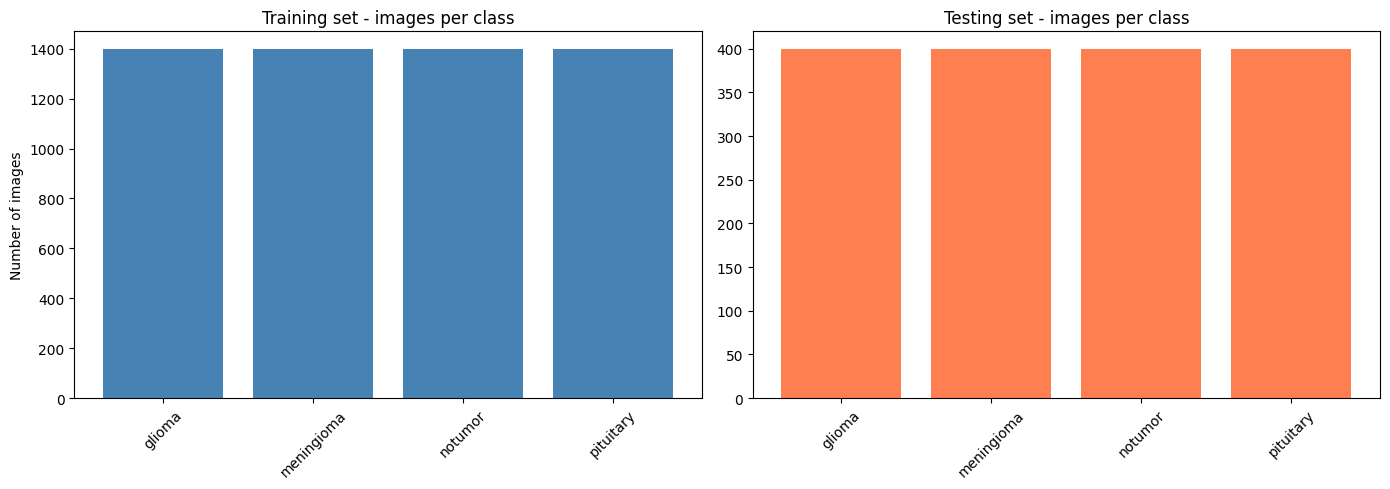

In [ ]:
import matplotlib.pyplot as plt

classes = sorted(os.listdir("data/Training"))

train_counts = {c: len(os.listdir(f"data/Training/{c}")) for c in classes}
test_counts  = {c: len(os.listdir(f"data/Testing/{c}"))  for c in classes}

print("Training set:")
for c, n in train_counts.items():
    print(f"  {c:14s}: {n}")
print(f"  {'TOTAL':14s}: {sum(train_counts.values())}")

print("\nTesting set:")
for c, n in test_counts.items():
    print(f"  {c:14s}: {n}")
print(f"  {'TOTAL':14s}: {sum(test_counts.values())}")

# Imbalance ratio - the key number for justifying class weights
ratio = max(train_counts.values()) / min(train_counts.values())
print(f"\nImbalance ratio (largest/smallest): {ratio:.2f}x")

# Side by side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values(), color="steelblue")
axes[0].set_title("Training set - images per class")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(test_counts.keys(), test_counts.values(), color="coral")
axes[1].set_title("Testing set - images per class")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Random Sample grid

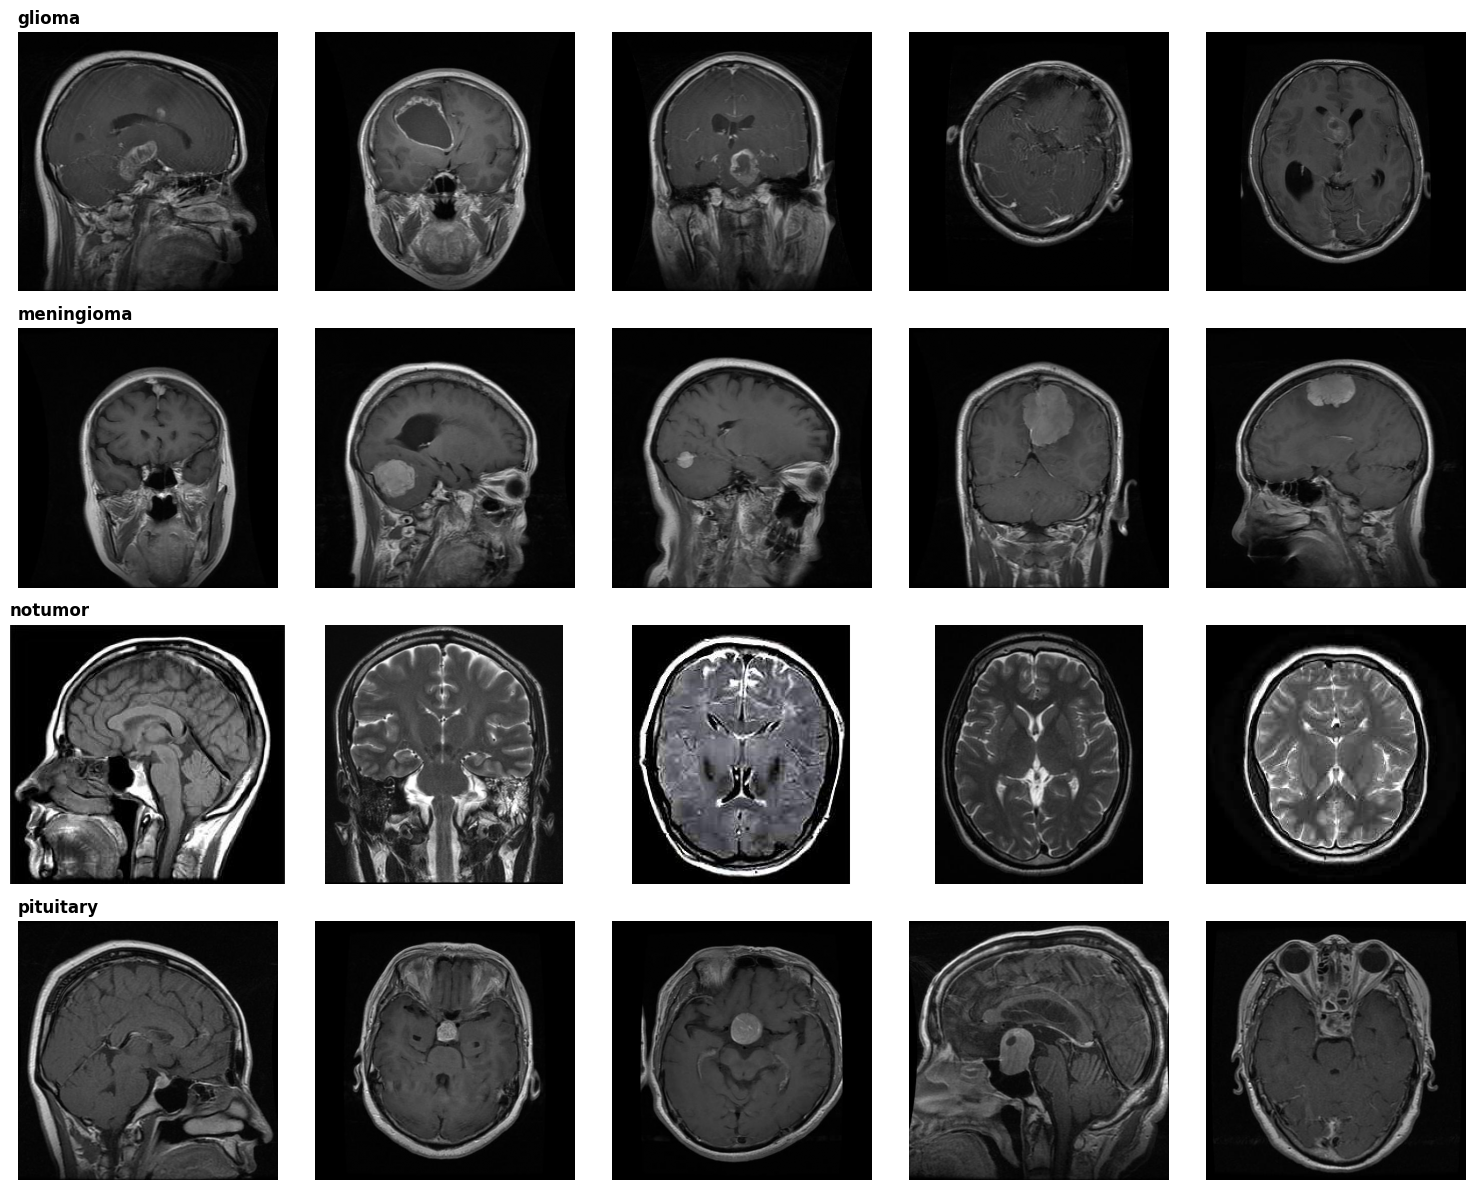

In [ ]:
import random

random.seed(42)   # so you see the same samples every run
n_per_class = 5

fig, axes = plt.subplots(len(classes), n_per_class,
                         figsize=(3 * n_per_class, 3 * len(classes)))

for row, c in enumerate(classes):
    folder = f"data/Training/{c}"
    all_files = os.listdir(folder)
    picks = random.sample(all_files, n_per_class)

    for col, fname in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(plt.imread(os.path.join(folder, fname)), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(c, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Pixel intensity distribution

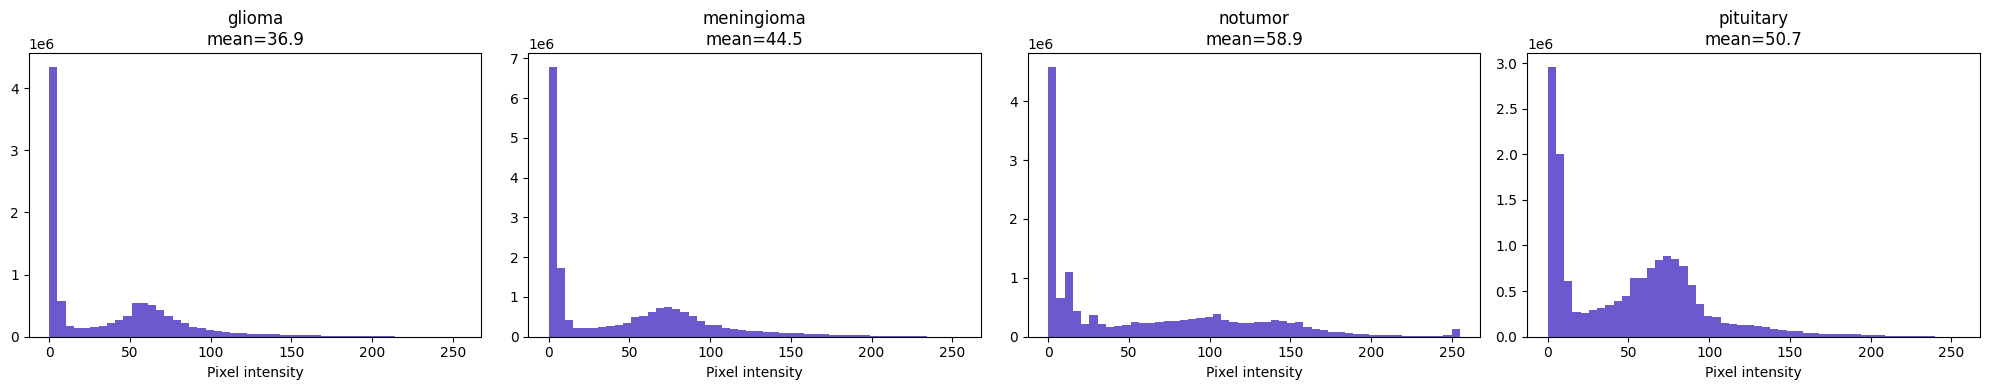

In [ ]:
import numpy as np

fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 4))

for ax, c in zip(axes, classes):
    folder = f"data/Training/{c}"
    picks = random.sample(os.listdir(folder), 30)

    all_pixels = []
    for fname in picks:
        img = plt.imread(os.path.join(folder, fname))
        all_pixels.append(img.ravel())

    pixels = np.concatenate(all_pixels)
    ax.hist(pixels, bins=50, color="slateblue")
    ax.set_title(f"{c}\nmean={pixels.mean():.1f}")
    ax.set_xlabel("Pixel intensity")

plt.tight_layout()
plt.show()

Block 6 — Cleaning and EDA summary

In [ ]:
print("=" * 55)
print("DATA CLEANING AND EDA SUMMARY")
print("=" * 55)
print(f"Corrupt images removed : {len(bad)}")
print(f"Total training images  : {sum(train_counts.values())}")
print(f"Total testing images   : {sum(test_counts.values())}")
print(f"Number of classes      : {len(classes)}")
print(f"Class names            : {classes}")
print(f"Distinct image sizes   : {len(sizes)}")
print(f"Most common size       : {sizes.most_common(1)[0][0]}")
print(f"Colour modes present   : {dict(modes)}")
print(f"Imbalance ratio        : {ratio:.2f}x")
print("=" * 55)
print("\nPreprocessing decisions justified by the above:")
print(f"  - Resize to 224x224   (because {len(sizes)} distinct sizes exist)")
print(f"  - Convert all to RGB  (because modes present: {list(modes.keys())})")
print(f"  - Use class weights   (because imbalance is {ratio:.2f}x)")
print("  - Mild augmentation only (medical images must stay anatomically valid)")

DATA CLEANING AND EDA SUMMARY
Corrupt images removed : 0
Total training images  : 5600
Total testing images   : 1600
Number of classes      : 4
Class names            : ['glioma', 'meningioma', 'notumor', 'pituitary']
Distinct image sizes   : 381
Most common size       : (512, 512)
Colour modes present   : {'L': 2358, 'RGB': 3238, 'RGBA': 3, 'P': 1}
Imbalance ratio        : 1.00x

Preprocessing decisions justified by the above:
  - Resize to 224x224   (because 381 distinct sizes exist)
  - Convert all to RGB  (because modes present: ['L', 'RGB', 'RGBA', 'P'])
  - Use class weights   (because imbalance is 1.00x)
  - Mild augmentation only (medical images must stay anatomically valid)


Block 7: Augmentation and preprocessing pipeline

In [ ]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def to_rgb(img):
    return img.convert("RGB")

train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),
])

eval_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined")

Transforms defined


Block 8: Datasets, train/val split, class weights, DataLoaders



In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
full_train = datasets.ImageFolder("data/Training", transform=train_tf)
full_eval  = datasets.ImageFolder("data/Training", transform=eval_tf)
test_ds    = datasets.ImageFolder("data/Testing",  transform=eval_tf)

class_names = full_train.classes
num_classes = len(class_names)

n = len(full_train)
n_val = int(0.2 * n)
perm = torch.randperm(n, generator=torch.Generator().manual_seed(42)).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_ds = Subset(full_train, train_idx)
val_ds   = Subset(full_eval,  val_idx)

train_labels = [full_train.samples[i][1] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = torch.tensor(
    class_counts.sum() / (num_classes * class_counts), dtype=torch.float
).to(device)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Class weights:")
for c, w in zip(class_names, class_weights):
    print(f"  {c:14s}: {w:.3f}")

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nBatches per epoch - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Train: 4480 | Val: 1120 | Test: 1600
Class weights:
  glioma        : 1.005
  meningioma    : 0.988
  notumor       : 0.990
  pituitary     : 1.017

Batches per epoch - train: 140, val: 35, test: 50


Block 9: Build the DenseNet-121 model with a 4-class head

In [ ]:
weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: DenseNet-121")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"New classifier head:  {model.classifier}")

Model: DenseNet-121
Total parameters:     6,957,956
Trainable parameters: 6,957,956
New classifier head:  Linear(in_features=1024, out_features=4, bias=True)


Block 10: Loss function, epoch runner, and fit helper

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

def run_epoch(loader, train=False, optimizer=None):
    model.train() if train else model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().tolist())
        y_pred.extend(out.argmax(1).cpu().tolist())
    torch.set_grad_enabled(True)

    avg_loss = total_loss / len(loader.dataset)
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, macro_f1

def fit(epochs, optimizer, scheduler=None, tag=""):
    best_f1 = 0.0
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True, optimizer=optimizer)
        va_loss, va_acc, va_f1 = run_epoch(val_loader)
        if scheduler:
            scheduler.step(va_loss)
        print(f"[{tag}] Ep {ep:2d} | tr_loss {tr_loss:.3f} tr_f1 {tr_f1:.3f} | "
              f"va_loss {va_loss:.3f} va_acc {va_acc:.3f} va_f1 {va_f1:.3f}")
        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), "best_model.pth")
    print(f"[{tag}] Best val macro-F1: {best_f1:.3f}")
    return best_f1

print("Training helpers ready")

Training helpers ready


Block 13: Phase A - train classifier head only

In [ ]:
# Freeze the pretrained backbone
for p in model.features.parameters():
    p.requires_grad = False

opt_a = torch.optim.AdamW(
    model.classifier.parameters(), lr=1e-3, weight_decay=1e-4
)

print("Phase A starting - backbone frozen, training head only")
print("-" * 60)
fit(epochs=4, optimizer=opt_a, tag="A/head")

Phase A starting - backbone frozen, training head only
------------------------------------------------------------
[A/head] Ep  1 | tr_loss 0.758 tr_f1 0.733 | va_loss 0.574 va_acc 0.816 va_f1 0.813
[A/head] Ep  2 | tr_loss 0.496 tr_f1 0.832 | va_loss 0.458 va_acc 0.846 va_f1 0.846
[A/head] Ep  3 | tr_loss 0.445 tr_f1 0.842 | va_loss 0.464 va_acc 0.842 va_f1 0.846
[A/head] Ep  4 | tr_loss 0.413 tr_f1 0.849 | va_loss 0.380 va_acc 0.886 va_f1 0.885
[A/head] Best val macro-F1: 0.885


0.8853937191079893

Block 14: Phase B - fine-tune the whole network

In [ ]:
# Unfreeze everything
for p in model.parameters():
    p.requires_grad = True

opt_b = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=1e-4
)
sched_b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_b, mode="min", factor=0.5, patience=2
)

print("Phase B starting - full network fine-tuning")
print("-" * 60)
fit(epochs=10, optimizer=opt_b, scheduler=sched_b, tag="B/finetune")

model.load_state_dict(torch.load("best_model.pth"))
print("\nLoaded best checkpoint")

Phase B starting - full network fine-tuning
------------------------------------------------------------
[B/finetune] Ep  1 | tr_loss 0.239 tr_f1 0.912 | va_loss 0.108 va_acc 0.963 va_f1 0.962
[B/finetune] Ep  2 | tr_loss 0.109 tr_f1 0.960 | va_loss 0.087 va_acc 0.970 va_f1 0.969
[B/finetune] Ep  3 | tr_loss 0.072 tr_f1 0.974 | va_loss 0.075 va_acc 0.973 va_f1 0.973
[B/finetune] Ep  4 | tr_loss 0.053 tr_f1 0.982 | va_loss 0.066 va_acc 0.976 va_f1 0.976
[B/finetune] Ep  5 | tr_loss 0.041 tr_f1 0.986 | va_loss 0.059 va_acc 0.982 va_f1 0.982
[B/finetune] Ep  6 | tr_loss 0.040 tr_f1 0.986 | va_loss 0.045 va_acc 0.987 va_f1 0.987
[B/finetune] Ep  7 | tr_loss 0.037 tr_f1 0.989 | va_loss 0.055 va_acc 0.984 va_f1 0.984
[B/finetune] Ep  8 | tr_loss 0.030 tr_f1 0.989 | va_loss 0.069 va_acc 0.979 va_f1 0.979
[B/finetune] Ep  9 | tr_loss 0.027 tr_f1 0.991 | va_loss 0.038 va_acc 0.991 va_f1 0.991
[B/finetune] Ep 10 | tr_loss 0.031 tr_f1 0.990 | va_loss 0.052 va_acc 0.986 va_f1 0.986
[B/finetune] Be

Block 15: Evaluate on held-out test set

TEST SET RESULTS
              precision    recall  f1-score   support

      glioma      0.997     0.812     0.895       400
  meningioma      0.896     0.990     0.941       400
     notumor      0.921     0.998     0.958       400
   pituitary      0.990     0.988     0.989       400

    accuracy                          0.947      1600
   macro avg      0.951     0.947     0.946      1600
weighted avg      0.951     0.947     0.946      1600

Macro ROC-AUC: 0.9892


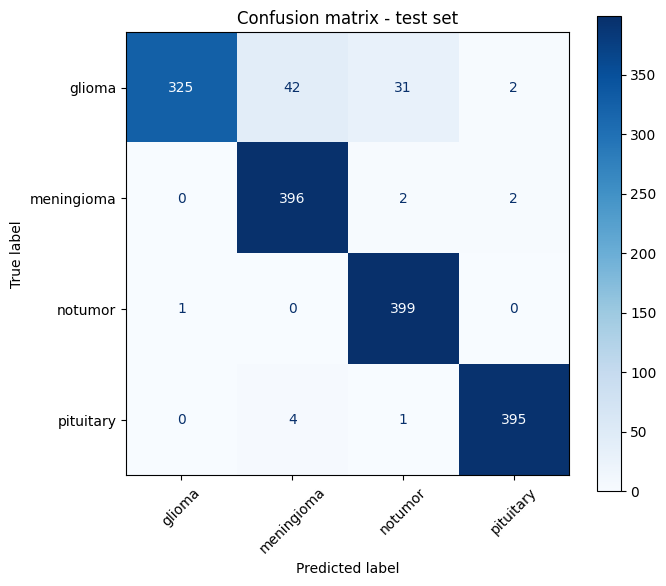


Class           Sensitivity  Specificity
------------------------------------------
glioma                0.812        0.999
meningioma            0.990        0.962
notumor               0.998        0.972
pituitary             0.988        0.997


In [ ]:
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        y_prob.append(torch.softmax(out, dim=1).cpu().numpy())
        y_true.append(y.numpy())

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = y_prob.argmax(1)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(classification_report(y_true, y_pred,
                             target_names=class_names, digits=3))

macro_auc = roc_auc_score(y_true, y_prob,
                           multi_class="ovr", average="macro")
print(f"Macro ROC-AUC: {macro_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    cmap="Blues", xticks_rotation=45, ax=ax
)
plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

print(f"\n{'Class':14s} {'Sensitivity':>12s} {'Specificity':>12s}")
print("-" * 42)
sens_list = []
for i, c in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP
    sens = TP / (TP + FN) if (TP + FN) else 0.0
    spec = TN / (TN + FP) if (TN + FP) else 0.0
    sens_list.append(sens)
    print(f"{c:14s} {sens:12.3f} {spec:12.3f}")

Block 16: Save model weights and metadata

In [ ]:
WEIGHTS_PATH = "brain_tumor_densenet121.pth"
META_PATH    = "model_metadata.json"

torch.save(model.state_dict(), WEIGHTS_PATH)

metadata = {
    "architecture"        : "densenet121",
    "num_classes"         : num_classes,
    "classes"             : class_names,
    "input_size"          : IMG_SIZE,
    "normalization"       : {"mean": MEAN, "std": STD},
    "gradcam_target_layer": "features.norm5",
    "metrics": {
        "macro_roc_auc": round(float(macro_auc), 4),
        "per_class_sensitivity": {
            c: round(float(s), 4)
            for c, s in zip(class_names, sens_list)
        },
    },
    "trained_at": datetime.datetime.utcnow().isoformat() + "Z",
}

with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

from google.colab import files
files.download(WEIGHTS_PATH)
files.download(META_PATH)

{
  "architecture": "densenet121",
  "num_classes": 4,
  "classes": [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
  ],
  "input_size": 224,
  "normalization": {
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  },
  "gradcam_target_layer": "features.norm5",
  "metrics": {
    "macro_roc_auc": 0.9892,
    "per_class_sensitivity": {
      "glioma": 0.8125,
      "meningioma": 0.99,
      "notumor": 0.9975,
      "pituitary": 0.9875
    }
  },
  "trained_at": "2026-07-24T17:47:17.083839Z"
}


/tmp/ipykernel_1494/2405514223.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.datetime.utcnow().isoformat() + "Z",


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>